# Tree Detection from Sentinel-2 Data

This notebook demonstrates how to train a binary classification model (Tree vs. Non-Tree) using the Sentinel-2 German National Forest Inventory dataset.

The process involves:
1. Inspecting the SQLite database structure.
2. Loading the data.
3. Unpacking binary Sentinel-2 band data.
4. Transforming labels into a binary target (Tree / Non-Tree).
5. Training and evaluating a Random Forest Classifier on a subset of matching bands.
6. Inspecting and applying the model to multiple new `.tif` images to predict tree probability.

In [11]:
import sqlite3
import pandas as pd
import numpy as np
import struct
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Configuration
DB_NAME = 'S2GNFI_V1.sqlite'
ROW_LIMIT = 1000000
TIF_FILE_PATHS = ['S2_hamburg_apr_25.tif', 'S2_vienna_nov_25.tif']

# Since the custom .tif image only has B02, B03, B04, and B08 (plus some indices),
# we train the model ONLY on these 4 raw bands to make it compatible.
TRAINING_BANDS = ['B2', 'B3', 'B4', 'B8']

## 1. Database Inspection
Before loading data, let's look at the structure of the SQL file to understand which tables and columns are available.

In [12]:
print(f"Inspecting database: {DB_NAME}")
conn = sqlite3.connect(DB_NAME)
cursor = conn.cursor()

# List all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]
print(f"Tables found: {tables}\n")

for table in tables:
    print(f"--- Structure of Table: {table} ---")
    cursor.execute(f"PRAGMA table_info({table});")
    schema = cursor.fetchall()
    for col in schema:
        # col structure: (id, name, type, notnull, default_value, pk)
        print(f"Column: {col[1]:<20} Type: {col[2]}")
    print("\n")

conn.close()

Inspecting database: S2GNFI_V1.sqlite
Tables found: ['data', 'meta_col', 'x_ba']

--- Structure of Table: data ---
Column: tnr                  Type: INT
Column: enr                  Type: INT
Column: tree_id              Type: INT
Column: species              Type: INT
Column: time                 Type: INT
Column: boa                  Type: 
Column: qai                  Type: INT
Column: is_train             Type: INT
Column: is_pure              Type: INT
Column: dbh_mm               Type: INT
Column: height_dm            Type: INT
Column: crown_area_m2        Type: REAL
Column: X_WGS84              Type: REAL
Column: Y_WGS84              Type: REAL
Column: is_corrected         Type: INT
Column: disturbance_year     Type: INT
Column: present_2022         Type: INT
Column: doy                  Type: INT


--- Structure of Table: meta_col ---
Column: table_name           Type: TEXT
Column: col_name             Type: TEXT
Column: type                 Type: TEXT
Column: description     

## 2. Load and Unpack Data
We automatically detect the data table and load a subset for training.

In [13]:
print("Connecting to database and fetching data...")
conn = sqlite3.connect(DB_NAME)

# Select the main data table (usually not 'x_ba')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
all_tables = [t[0] for t in cursor.fetchall()]
data_table = [t for t in all_tables if t != 'x_ba'][0]

query = f"SELECT * FROM {data_table} LIMIT {ROW_LIMIT}"
df = pd.read_sql_query(query, conn)
conn.close()

print(f"Successfully loaded {len(df)} rows from '{data_table}'.")

Connecting to database and fetching data...
Successfully loaded 1000000 rows from 'data'.


In [14]:
print("Unpacking Sentinel-2 band data (BOA)...")

def unpack_boa(blob):
    # Unpack 20-byte blob into 10 signed 16-bit integers
    return struct.unpack('10h', blob)

df['boa_unpacked'] = df['boa'].apply(unpack_boa)

# The blob always contains 10 bands, so we unpack all of them first
all_band_names = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
boa_df = pd.DataFrame(df['boa_unpacked'].tolist(), columns=all_band_names)
df = pd.concat([df, boa_df], axis=1)

print("Data unpacked successfully.")

Unpacking Sentinel-2 band data (BOA)...
Data unpacked successfully.


## 3. Binary Labeling and Split
Convert tree species IDs into a simple binary target: 1 (Tree) or 0 (Non-Tree background).

In [15]:
print("Preparing labels and split...")

# Positive tree_id means it's a tree from the inventory
df['is_tree'] = (df['tree_id'] > 0).astype(int)

train_data = df[df['is_train'] == 1]
test_data = df[df['is_train'] == 0]

# We strictly select ONLY the 4 bands that match our custom .tif file
X_train = train_data[TRAINING_BANDS]
y_train = train_data['is_tree']

X_test = test_data[TRAINING_BANDS]
y_test = test_data['is_tree']

print(f"Training set: {len(X_train)} | Test set: {len(X_test)}")
print(f"Using features: {TRAINING_BANDS}")

Preparing labels and split...
Training set: 641006 | Test set: 358994
Using features: ['B2', 'B3', 'B4', 'B8']


## 4. Model Training
Training the Random Forest Classifier using all available CPU cores.

In [16]:
print("Training Random Forest (100 trees)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model training finished.")

Training Random Forest (100 trees)...
Model training finished.


## 5. Evaluation

In [17]:
print("Evaluating on test data...")
preds = rf_model.predict(X_test)

acc = accuracy_score(y_test, preds)
print("=" * 40)
print(f"Final Accuracy: {acc * 100:.2f}%")
print("=" * 40)
print(classification_report(y_test, preds, target_names=['Non-Tree', 'Tree']))

Evaluating on test data...
Final Accuracy: 96.33%
              precision    recall  f1-score   support

    Non-Tree       0.57      0.54      0.56     15279
        Tree       0.98      0.98      0.98    343715

    accuracy                           0.96    358994
   macro avg       0.78      0.76      0.77    358994
weighted avg       0.96      0.96      0.96    358994



## 6. Applying the Model to Custom .tif Images
Now that the model is trained, we can load multiple external Sentinel-2 `.tif` images and predict the presence of trees pixel by pixel.

**Note:** To run this section, you need to install `rasterio` and `matplotlib` (e.g., `pip install rasterio matplotlib`).

In [18]:
import os
import rasterio
import matplotlib.pyplot as plt

### 6.1 Inspecting the .tif Files
We check if all images have the expected structure.

In [19]:
for file_path in TIF_FILE_PATHS:
    if os.path.exists(file_path):
        print(f"\nInspecting image: {file_path}")
        with rasterio.open(file_path) as src:
            print("--- TIF Profile ---")
            print(f"Number of Bands : {src.count}")
            print(f"Width x Height  : {src.width} x {src.height} pixels")
            print(f"Data Type       : {src.dtypes[0]}")
            print(f"Coordinate Ref  : {src.crs}\n")
            
            print("--- Health Check ---")
            if src.count >= 4:
                print("✅ Image has at least 4 bands.")
                print("⚠️ We will assume the first 4 bands are: Blue, Green, Red, NIR (B02, B03, B04, B08).")
            else:
                print(f"⚠️ ERROR: Model expects at least 4 bands, but this image has {src.count}.")
    else:
        print(f"\nFile not found: {file_path}. Please provide a valid path.")


Inspecting image: S2_hamburg_apr_25.tif
--- TIF Profile ---
Number of Bands : 7
Width x Height  : 2394 x 909 pixels
Data Type       : float32
Coordinate Ref  : EPSG:4326

--- Health Check ---
✅ Image has at least 4 bands.
⚠️ We will assume the first 4 bands are: Blue, Green, Red, NIR (B02, B03, B04, B08).

Inspecting image: S2_vienna_nov_25.tif
--- TIF Profile ---
Number of Bands : 7
Width x Height  : 4961 x 2195 pixels
Data Type       : float32
Coordinate Ref  : EPSG:4326

--- Health Check ---
✅ Image has at least 4 bands.
⚠️ We will assume the first 4 bands are: Blue, Green, Red, NIR (B02, B03, B04, B08).


### 6.2 Running the Prediction (Probability)
We extract the first 4 bands from each image and feed them to the Random Forest. Instead of a hard classification (0 or 1), we now ask for the probability (0.0 to 1.0) of a pixel being a tree.


--- Processing S2_hamburg_apr_25.tif ---
Extracting the first 4 bands (B2, B3, B4, B8)...
Flattening image for prediction...
Predicting probabilities on 2176146 pixels...


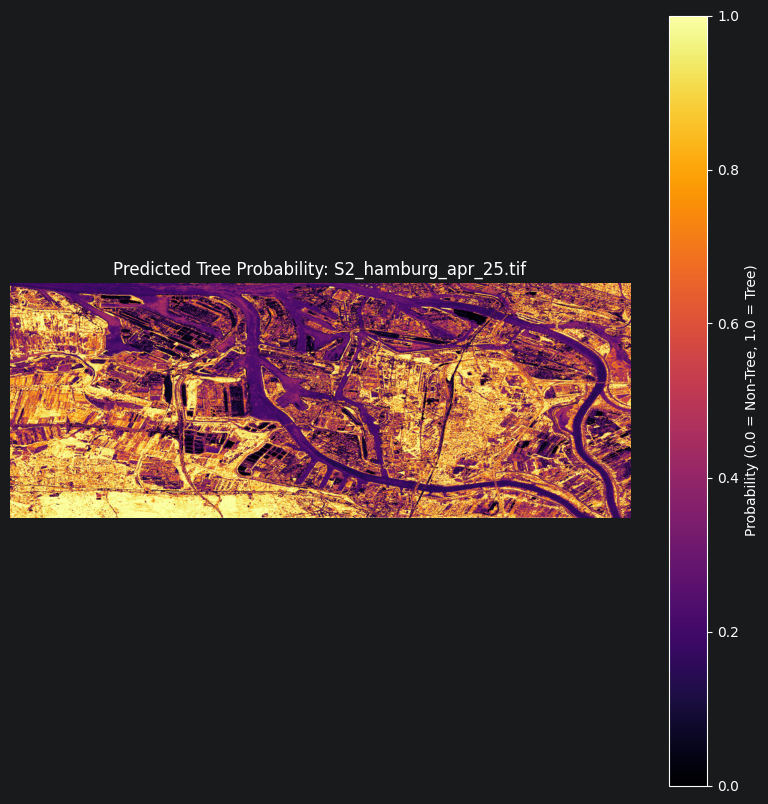


--- Processing S2_vienna_nov_25.tif ---
Extracting the first 4 bands (B2, B3, B4, B8)...
Flattening image for prediction...
Predicting probabilities on 10889395 pixels...


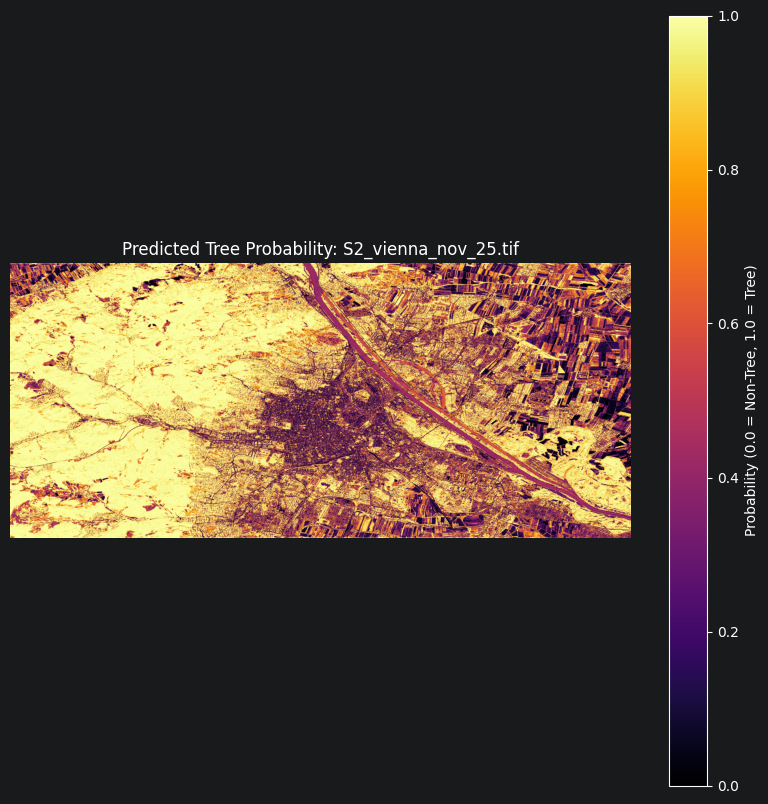

In [20]:
for file_path in TIF_FILE_PATHS:
    if os.path.exists(file_path):
        print(f"\n--- Processing {file_path} ---")
        with rasterio.open(file_path) as src:
            # Read all bands
            img = src.read()
            num_bands, height, width = img.shape
            
            if num_bands >= 4:
                print("Extracting the first 4 bands (B2, B3, B4, B8)...")
                # Slice the array to only keep the first 4 bands and ignore NDVI, EVI, SAVI
                img_subset = img[0:4, :, :]
                
                print("Flattening image for prediction...")
                # Change shape to (total_pixels, 4_bands)
                flattened_img = img_subset.transpose(1, 2, 0).reshape(-1, 4)
                
                print(f"Predicting probabilities on {flattened_img.shape[0]} pixels...")
                # Convert to DataFrame to avoid feature name warnings
                flattened_df = pd.DataFrame(flattened_img, columns=TRAINING_BANDS)
                
                # Use predict_proba instead of predict. 
                # It returns an array of shape (n_samples, n_classes).
                # We want the probability for class 1 (Tree), which is at index 1.
                probabilities = rf_model.predict_proba(flattened_df)[:, 1]
                
                # Reshape back to image dimensions
                tree_prob_mask = probabilities.reshape(height, width)
                
                plt.figure(figsize=(10, 10))
                plt.title(f'Predicted Tree Probability: {file_path}')
                # We use vmin=0.0 and vmax=1.0 to fix the color scale limits
                plt.imshow(tree_prob_mask, cmap='inferno', vmin=0.0, vmax=1.0)
                plt.colorbar(label='Probability (0.0 = Non-Tree, 1.0 = Tree)')
                plt.axis('off')
                plt.show()
            else:
                print(f"Prediction aborted for {file_path}: Image needs at least 4 bands.")